<a href="https://colab.research.google.com/github/Carlogui/IMEC_3345/blob/Tarea_Estudio_caso_Distritos_Energ%C3%A9ticos/Distritos_Energ%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

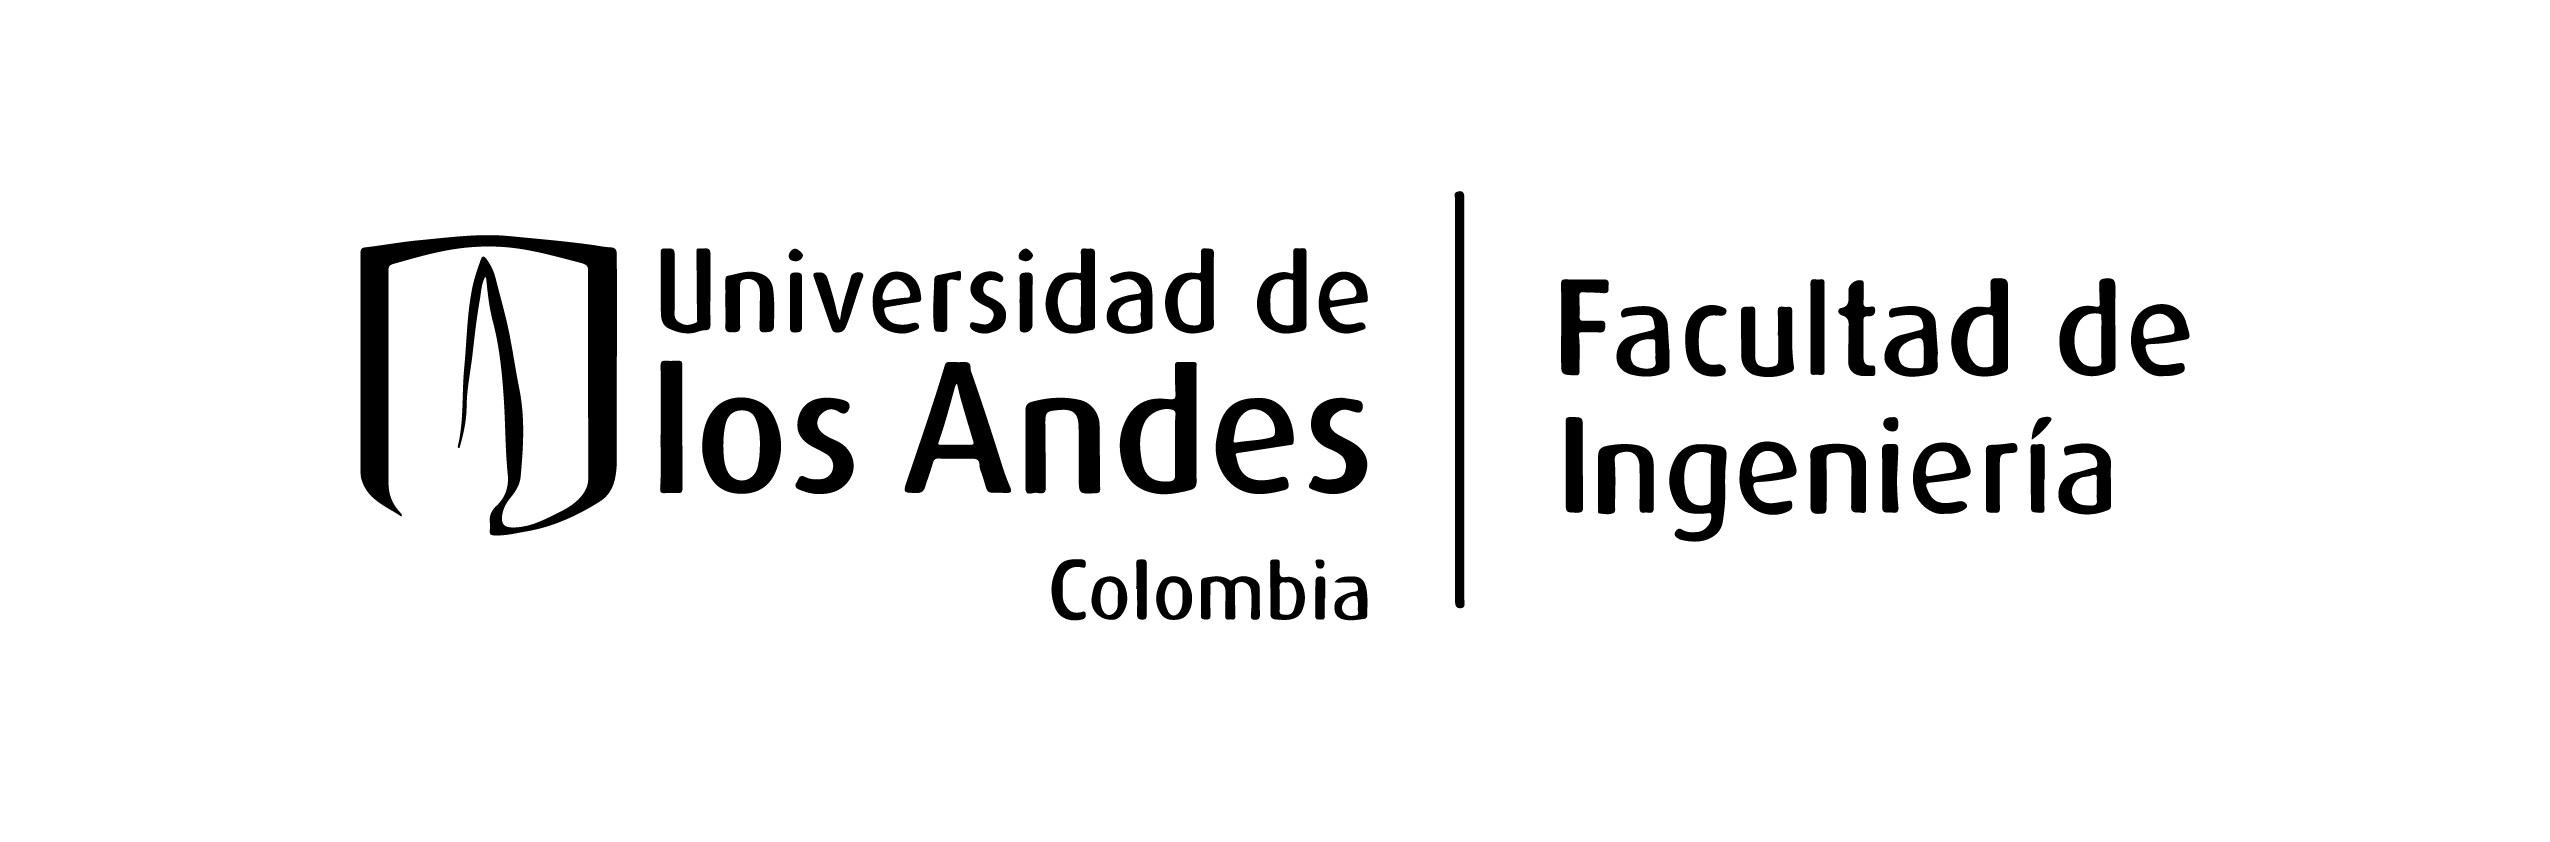

<font color='black' align="center"><h1> </h1></font>

<font color='black'><h1 align="center">IMEC 3345 - Sistemas de Conversión de Energía</h1></font>

<font color='black'><h1 align="center">Profesor: Andres Gonzalez Mancera </h1></font>

<font color='black'><h1 align="center">Estudio de caso - Distritos Energéticos
</h1></font>

<font color='black'><h1 align="center">Carlos Ernesto Upegui - 202213004</h1></font>

<br>

<br>

<font color='black'><center>Septiembre 26 2025<br>Segundo Semestre 2025 <br>Bogotá DC – Colombia </center><br></font>

In [3]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


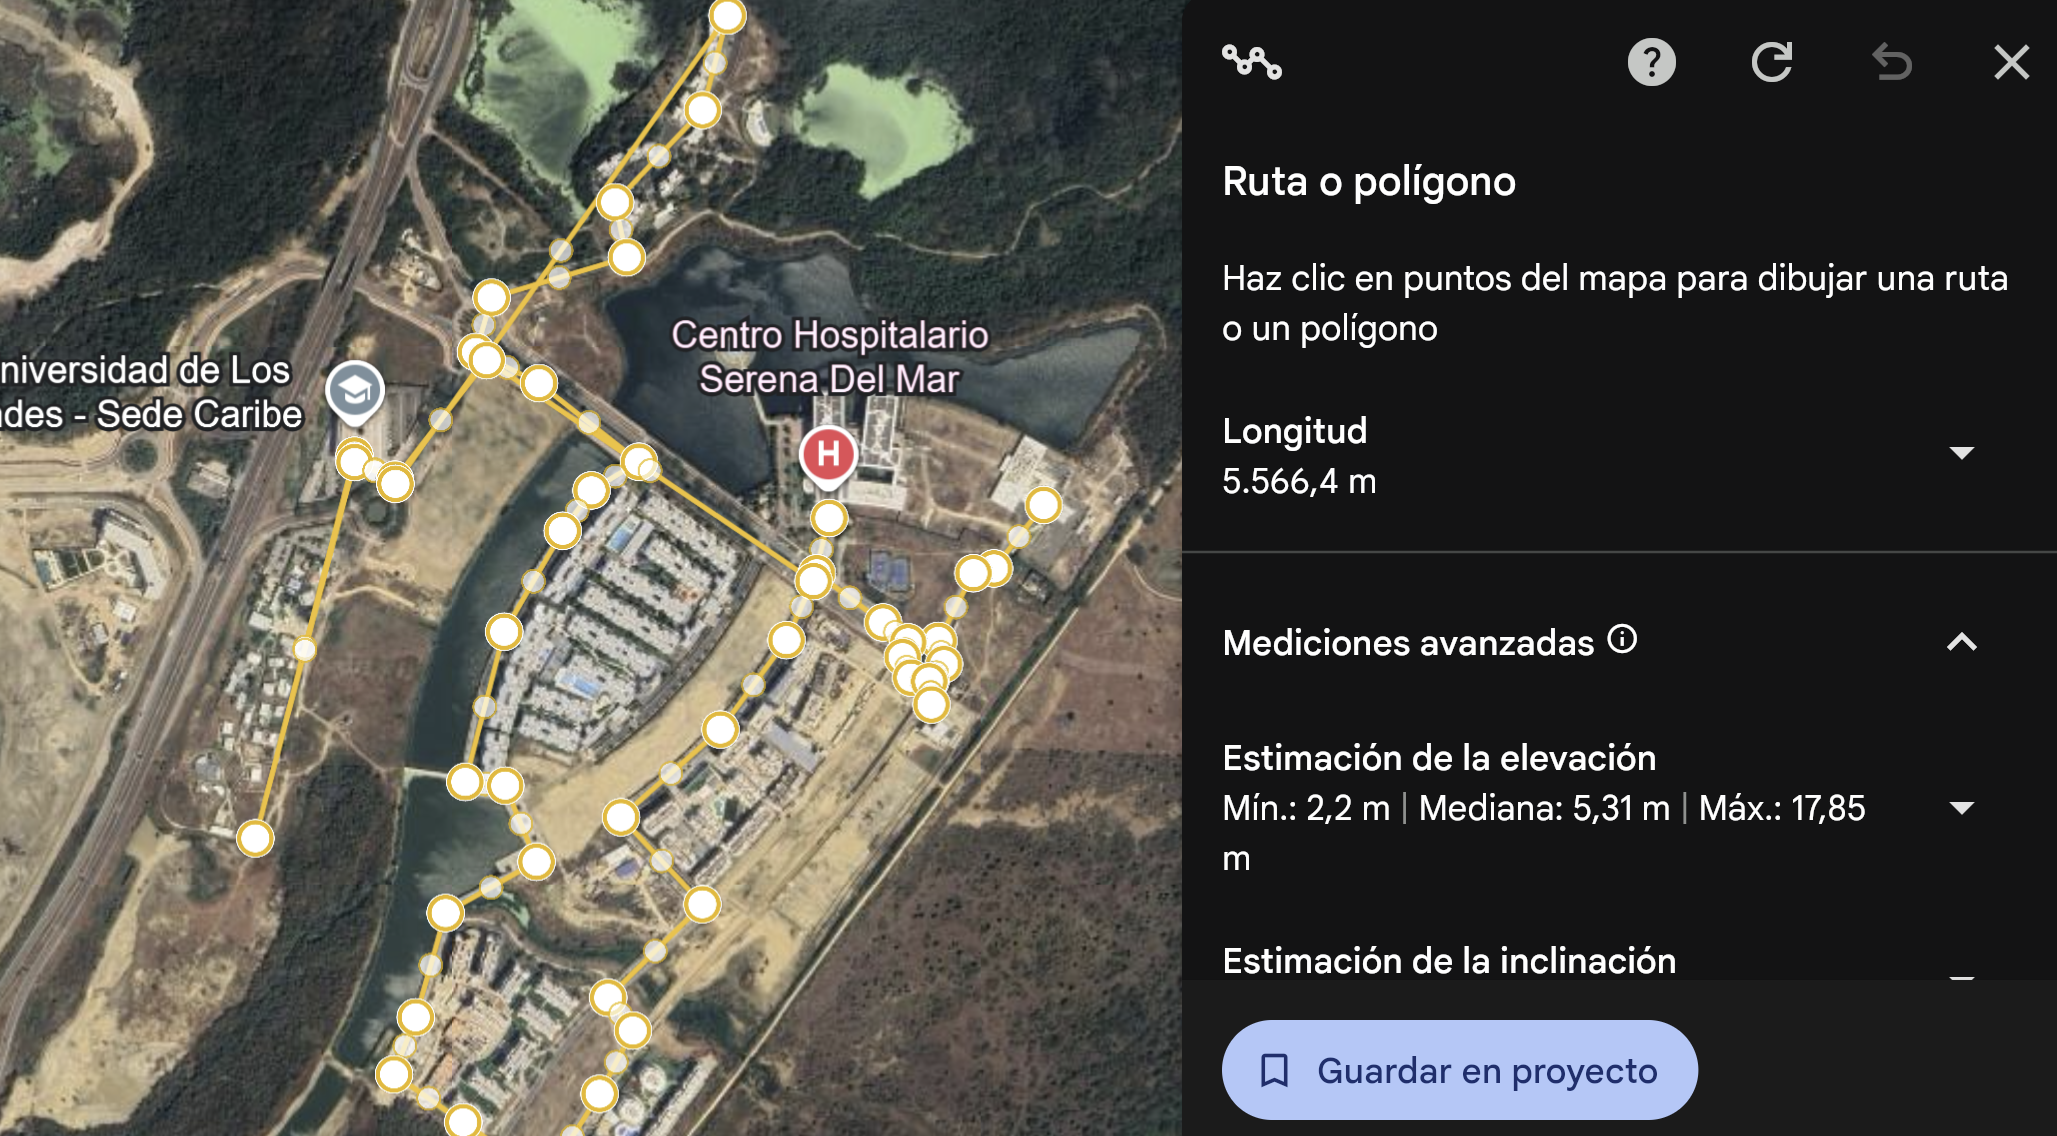

In [5]:
L_ida_m = 5566.4                       # m
L_total_m = 2 * L_ida_m                # m ida + retorno

# Geometría/propiedades térmicas
r1 = 0.10        # m, radio exterior tubería sin aislamiento (≈ DN200)
e_aisl = 0.05    # m, espesor del aislamiento
r2 = r1 + e_aisl
k_aisl = 0.030   # W/(m·K), conductividad del aislamiento
DeltaT = 17.0    # K, diferencia típica suelo-agua

# Pérdida lineal por conducción cilíndrica
q_line_Wm = (2 * math.pi * k_aisl * DeltaT) / math.log(r2 / r1)   # W/m
Q_loss_kW = q_line_Wm * L_total_m / 1000.0                        # kW


TR_totales = 860
kW_por_TR_base = 1.8
kW_por_TR_distrito = 1.04
P_pico_edificio_kW = TR_totales * 3.516            # ≈ 3023 kW_frío
P_cap_distrito_kW = 1704 * 3.516                   # ≈ 5991 kW_frío

pct_vs_edificio = 100 * Q_loss_kW / P_pico_edificio_kW
pct_vs_distrito = 100 * Q_loss_kW / P_cap_distrito_kW

E_ahorro_kWh = 1_307_200  # ahorro anual reportado
P_base_kW = TR_totales * kW_por_TR_base
P_dist_kW = TR_totales * kW_por_TR_distrito
E_base_kWh = E_ahorro_kWh / 0.40
E_dist_kWh = E_base_kWh * 0.60

h_base = E_base_kWh / P_base_kW
h_dist = E_dist_kWh / P_dist_kW
ahorro_potencia_pct = 100 * (1 - (kW_por_TR_distrito / kW_por_TR_base))


EF_cog = 0.203  # kgCO2e/kWh, del caso
tCO2_base_elec = E_base_kWh * EF_cog / 1000.0
tCO2_dist_elec = E_dist_kWh * EF_cog / 1000.0
delta_elec_t = tCO2_base_elec - tCO2_dist_elec

N_eq = 662       # minisplits retirados
C_kg = 1.24      # kg de R-410A por equipo (promedio)
f_leak = 0.10    # 10%/año
GWP_410A = 2088

tCO2_refri_t = (N_eq * C_kg * f_leak * GWP_410A) / 1000.0
delta_total_t = delta_elec_t + tCO2_refri_t


resultados = pd.DataFrame({
    "Parámetro": [
        "Longitud (ida) [m]", "Longitud total (ida+ret) [m]",
        "Pérdida lineal q' [W/m]", "Pérdida total Q_loss [kW]",
        "% de la potencia pico del edificio", "% de la capacidad del distrito",
        "Potencia base [kW]", "Potencia distrito [kW]", "Ahorro por potencia [%]",
        "Energía base [MWh/año]", "Energía distrito [MWh/año]",
        "Horas eq. base [h/año]", "Horas eq. distrito [h/año]",
        "GEI evitado por electricidad [tCO2e/año]",
        "GEI evitado por refrigerante [tCO2e/año]",
        "GEI total evitado [tCO2e/año]"
    ],
    "Valor": [
        round(L_ida_m,1), round(L_total_m,1),
        round(q_line_Wm,2), round(Q_loss_kW,2),
        round(pct_vs_edificio,2), round(pct_vs_distrito,2),
        round(P_base_kW,1), round(P_dist_kW,1), round(ahorro_potencia_pct,2),
        round(E_base_kWh/1000,1), round(E_dist_kWh/1000,1),
        round(h_base,0), round(h_dist,0),
        round(delta_elec_t,2), round(tCO2_refri_t,2), round(delta_total_t,2)
    ]
})

print(resultados)

                                   Parámetro     Valor
0                         Longitud (ida) [m]   5566.40
1               Longitud total (ida+ret) [m]  11132.80
2                    Pérdida lineal q' [W/m]      7.90
3                  Pérdida total Q_loss [kW]     87.98
4         % de la potencia pico del edificio      2.91
5             % de la capacidad del distrito      1.47
6                         Potencia base [kW]   1548.00
7                     Potencia distrito [kW]    894.40
8                    Ahorro por potencia [%]     42.22
9                     Energía base [MWh/año]   3268.00
10                Energía distrito [MWh/año]   1960.80
11                    Horas eq. base [h/año]   2111.00
12                Horas eq. distrito [h/año]   2192.00
13  GEI evitado por electricidad [tCO2e/año]    265.36
14  GEI evitado por refrigerante [tCO2e/año]    171.40
15             GEI total evitado [tCO2e/año]    436.76


<font color='black'> <p>El sistema de enfriamiento opera con una arquitectura “planta → edificio”. En la planta central de Serena del Mar se realiza trigeneración a gas natural: las microturbinas producen electricidad y gases calientes. Ese calor residual alimenta chillers de absorción, mientras chillers eléctricos cubren modulación y picos. El agua helada y el agua caliente viajan por redes subterráneas hacia los usuarios. En el campus, un anillo de tuberías preaisladas lleva y retorna el agua helada. Al llegar a Altana, una estación de transferencia con intercambiadores, bombas secundarias y medición desacopla hidráulicamente la red del edificio. En los apartamentos, los fan-coils  suministran el frío. El distrito entrega frío a 1.04 kW/TR y, comparado a minisplits de, muestra un ahorro eléctrico del orden del 40%.</p><p>Pérdidas térmicas de transporte (con la longitud medida): con la ruta trazada en Google Earth de 5.566,4 m (solo ida), se evaluó la conducción a través del aislamiento cilíndrico de la tubería:
<br><br><span>q′</span> = 2πk ΔT / ln(<i>r</i><sub>2</sub>/<i>r</i><sub>1</sub>)   →   <span>Q̇</span><sub>pérd</sub> = <span>q′</span> · (2L)<br><br>Usando los siguientes valores para el primario (radio exterior sin aislamiento <i>r</i><sub>1</sub>=0,10 m, espesor de aislamiento 0,05 m, k=0,030 W/m·K y ΔT suelo-agua=17 K), resulta q′=7,9 W/m y, para ida+devuelta (2L=11.132,8 m), una pérdida total de Q̇≈88 kW. Esto es igual a 25 TR (1 TR=3,517 kW), entonces, es casi igual a 2,9 % del pico del edificio ( aproximadamente 860 TR) y 1,5 % de la capacidad del distrito (1.704 TR). Con buen aislamiento, las pérdidas de red son por tanto moderadas frente a la demanda.</p><p>El 40% de ahorro reportado se justifica termodinámicamente por tres razones. Primero, el efecto de escala, los chillers centrales tienen COP superiores a los minisplits. Segundo, el aprovechamiento del calor residual de las microturbinas en chillers de absorción permite convertir parte de esa energía térmica en frío útil. Tercero, la operación centralizada mejora el desempeño a cargas parciales, y reduce sobrepotencias.</p><p>Ahorro = 1 − (1.04 / 1.8) = 42,2%</p><p> El estudio cuantifica para Altana un ahorro eléctrico anual de 1.307.200 kWh.</p><p> Si el ahorro anual es 1.307.200 kWh, la línea base resulta <span>E</span><sub>b</sub>=1.307.200/0,4 = 3.268.000 kWh/año y el proyecto consume <span>E</span><sub>p</sub>=1.960.800 kWh/año. Con un factor de emisión de la cogeneración a gas de 0,203 kgCO₂e/kWh, las emisiones energéticas son 663,4 tCO₂e/año en la línea base y 398,0 tCO₂e/año en el proyecto, para una reducción de 265,4 tCO₂e/año. Al eliminar 662 minisplits con refrigerante HFC-410A (10%/año de fuga, carga típica de 1,24 kg/equipo, GWP=2088) se evitan 171–172 tCO₂e/año adicionales. La reducción total se sitúa en torno a 437 tCO₂e/año, coherente con lo que dice del estudio.</p><p> Sustituir el gas de la planta por electricidad del SIN reduce emisiones si el factor de red es menor que el de la cogeneración:<br>ΔtCO₂e = <span>E</span><sub>p</sub> · (EF<sub>SIN</sub> − 0,203) / 1000.<br>Como la matriz eléctrica colombiana es predominantemente hidráulica, es razonable esperar EF<sub>SIN</sub>&lt;0,203. Por ejemplo, con EF<sub>SIN</sub>=0,12 kg/kWh, las emisiones del proyecto serían ~235 t/año (vs 398 t/año con cogeneración), es decir, ~163 t/año menos, sin contar la eliminación de fugas de HFC por la sustitución de minisplits.</p><p>En cuanto al almacenamiento térmico (TES), Puede implementarse como tanque de agua helada (6–12 °C) o como hielo (carga nocturna a COP alto y descarga diurna). Para cubrir <em>x</em> horas del pico de 860 TR:
<br>Capacidad = 860·<em>x</em> TR·h,  con  1 TR·h = 3,517 kWh<sub>th</sub> → <span>E</span>=3,517·860·<em>x</em> kWh<sub>th</sub>.
<br>Operativamente, el TES recorta el pico eléctrico de los chillers, mejora COP al desplazar operación a zonas eficientes, suaviza caudales (y pérdidas de red) y aporta flexibilidad tarifaria y resiliencia.</p>
</font>
